<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/ai_proj/workshop_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analytics Workshop
## เชิงปฏิบัติการ — สมอ. และ สนักงานอ้อย

โค้ดตัวอย่างทั้งหมดในอบรรม—คลิก "เปิดใน Colab" เพื่อรันได้ทันที

---
## ส่วนที่ 1: โหลดข้อมูลด้วย Python

In [1]:
import pandas as pd
import requests

# Internal: ทะเบียนผู้ประกอบการ
factory = pd.read_csv("factory_registration.csv")

# External API: กรมศุลการ (สมมติ) — mock fallback หากไม่มีเครือข่าย
try:
    resp = requests.get("https://api.customs.go.th/trade/sugar", timeout=5)
    trade_data = resp.json()
except Exception:
    print("[Warning] \u0e44ม่\u0e2a\u0e32\u0e21\u0e32\u0e23\u0e16\u0e40\u0e0a\u0e37\u0e48\u0e2d\u0e21\u0e15\u0e48\u0e2d API \u0e44\u0e14\u0e49 — \u0e43\u0e0a\u0e49 mock data")
    trade_data = {"status": "mock", "records": []}

# External: ข้อมูลเกศตร
agri = pd.read_excel("cane_production_2025.xlsx")

[Warning] ไม่สามารถเชื่อมต่อ API ได้ — ใช้ mock data


---
## ส่วนที่ 2: Data Quality Check

In [2]:
df = pd.read_csv("certification_data.csv")

print(" Missing values:\n", df.isnull().sum())
print(" Duplicates:", df.duplicated().sum())
print(" Shape:", df.shape)
print(" Data types:\n", df.dtypes)

# ตรวจสอบวันที่
df["cert_date"] = pd.to_datetime(df["cert_date"])
print(" Date range:", df["cert_date"].min(), "–", df["cert_date"].max())

 Missing values:
 cert_id               0
tis_no                0
factory_name          0
factory_size          0
province              0
industry_type         0
cert_count            0
cert_date             0
month                 0
sugar_price           0
product_type          0
years_certified       0
num_audit_findings    0
non_compliant         0
gdp_growth            0
new_factory_count     0
import_tariff         0
industry_index        0
application_count     0
dtype: int64
 Duplicates: 0
 Shape: (200, 19)
 Data types:
 cert_id                 int64
tis_no                 object
factory_name           object
factory_size            int64
province               object
industry_type          object
cert_count              int64
cert_date              object
month                   int64
sugar_price           float64
product_type            int64
years_certified         int64
num_audit_findings      int64
non_compliant           int64
gdp_growth            float64
new_factory_coun

---
## ส่วนที่ 3: Descriptive Analytics — Central Tendency

In [3]:
import pandas as pd

df = pd.read_csv("cane_production.csv")

mean_yield = df["yield_per_rai"].mean()
median_rai = df["yield_per_rai"].median()
mode_rai = df["yield_per_rai"].mode()[0]

print(f"Mean yield:   {mean_yield:.2f} กิโลกรัม/ไร่")
print(f"Median yield: {median_rai:.2f} กิโลกรัม/ไร่")
print(f"Mode yield:   {mode_rai:.2f} กิโลกรัม/ไร่")

if mean_yield > median_rai:
    print("→ มีเกษตรกรรัยได้ผลผลิตสูงมาก (ขวาเบ้)")
elif mean_yield < median_rai:
    print("→ เกษตรกรส่วนใหญ่ได้ผลผลิตต่ำ (ซ้ายเบ้)")
else:
    print("→ กระจัยตัวสมมาตร")

Mean yield:   15.14 กิโลกรัม/ไร่
Median yield: 15.20 กิโลกรัม/ไร่
Mode yield:   15.20 กิโลกรัม/ไร่
→ เกษตรกรส่วนใหญ่ได้ผลผลิตต่ำ (ซ้ายเบ้)


---
## ส่วนที่ 4: Descriptive Analytics — Dispersion

In [4]:
# วิเคราะห์การกระจัยของราคาน้ำตาล
prices = df["sugar_price"]

print(f"Std Dev: {prices.std():,.2f}")
print(f"Variance: {prices.var():,.2f}")
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
iqr = Q3 - Q1
print(f"IQR: {iqr:,.2f}")

lower = Q1 - 1.5 * iqr
upper = Q3 + 1.5 * iqr
outliers = df[(prices < lower) | (prices > upper)]
print(f"Outlier found: {len(outliers)} เดือน")

Std Dev: 4.31
Variance: 18.58
IQR: 7.37
Outlier found: 0 เดือน


---
## ส่วนที่ 5: Correlation Analysis

In [5]:
# ความสัมพันธ์ระหว่างปริมาณน้ำฝนกับผลผลิตอ้อย
corr = df["rainfall_mm"].corr(df["yield_per_rai"])
print(f"r = {corr:.3f}")
# r > 0 → ฝนมาก ผลผลิตมากขึ้น
# r < 0 → ฝนมาก ผลผลิตลดลง (น้ำท่วม)
# r ≈ 0 → ไม่สัมพันธ์กัน

r = 0.215


---
## ส่วนที่ 6: Visualization

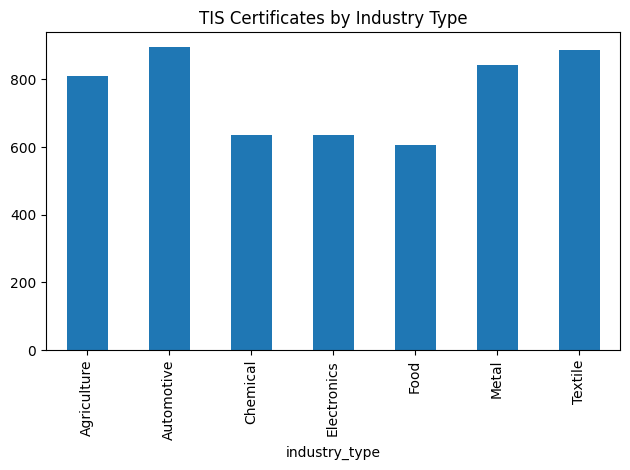

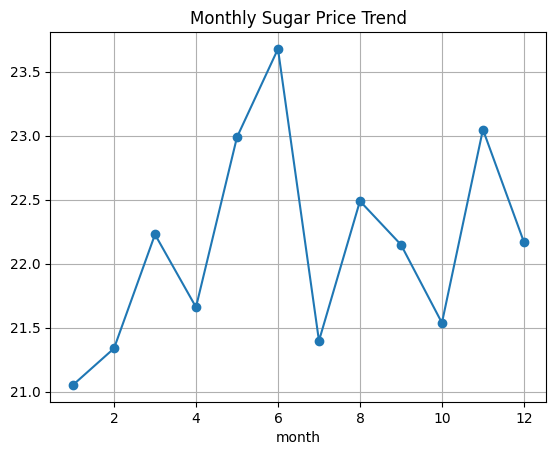

In [6]:
import matplotlib.pyplot as plt

# Reload certification data (has industry_type, cert_count, month, sugar_price)
df = pd.read_csv("certification_data.csv")

# Bar Chart: มอก. แยกตามประเภท
df.groupby("industry_type")["cert_count"].sum() \
  .plot(kind="bar")
plt.title("TIS Certificates by Industry Type")
plt.tight_layout()
plt.show()

# Line Chart: ราคาน้ำตาล
df.groupby("month")["sugar_price"].mean() \
  .plot(kind="line", marker="o")
plt.title("Monthly Sugar Price Trend")
plt.grid(True)
plt.show()

---
## ส่วนที่ 7: Predictive Analytics — Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

df = pd.read_csv("cane_production.csv")
X = df[["rainfall_mm", "fertilizer_kg",
        "area_rai"]]
y = df["yield_per_rai"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict([[1200, 50, 10]])
print(f"พยากรณ์ผลผลิต: {pred[0]:.2f} กก./ไร่")

for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef:.2f}")

พยากรณ์ผลผลิต: 16.41 กก./ไร่
rainfall_mm: 0.00
fertilizer_kg: -0.00
area_rai: -0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## ส่วนที่ 8: Classification — ความเสี่ยงสินค้าไม่ได้มาตรฐาน

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("certification_data.csv")
X = df[["factory_size", "years_certified",
        "num_audit_findings", "product_type"]]
y = df["non_compliant"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.00%


---
## ส่วนที่ 9: พยากรณ์แนวโน้มการขอ มอก.

In [9]:
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("certification_data.csv")
features = ["gdp_growth", "new_factory_count",
            "import_tariff", "industry_index"]
X = df[features]
y = df["application_count"]

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

for feat, imp in zip(features, model.feature_importances_):
    print(f"{feat}: {imp:.2%}")

gdp_growth: 27.32%
new_factory_count: 16.57%
import_tariff: 27.14%
industry_index: 28.97%


---
## ส่วนที่ 10: K-Means Clustering — จัดกลุ่มเกษตรกร

In [10]:
from sklearn.cluster import KMeans

df = pd.read_csv("cane_production.csv")
X = df[["area_rai", "yield_per_rai", "cost_per_rai",
        "ccs_percentage"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["farmer_group"] = kmeans.fit_predict(X)

print(df.groupby("farmer_group").agg({
    "area_rai": "mean", "yield_per_rai": "mean"
}))

# Group 0 = ศักยภาพสูง
# Group 1 = ศักยภาพปานกลาง
# Group 2 = ต้องการพัฒนา

                area_rai  yield_per_rai
farmer_group                           
0             105.433750      15.226000
1             106.708475      14.865932
2              89.816393      15.307541


---
## ส่วนที่ 11: ETL Pipeline

In [11]:
import pandas as pd
import sqlite3

# Extract: ดึงข้อมูลจากหลายแหล่ง
conn = sqlite3.connect("factory.db")
factory = pd.read_sql("SELECT * FROM factories", conn)
trade = pd.read_csv("sugar_export_2025.csv")
weather = pd.read_json("rainfall_data.json")

# Transform: รวมและทำความสะอาด
merged = factory.merge(trade, on="province", how="left")
merged["year"] = pd.to_datetime(merged["date"]).dt.year
merged = merged.dropna(subset=["factory_id"])

# Load: บันทึกลง Data Warehouse
conn_dw = sqlite3.connect("warehouse.db")
merged.to_sql("agg_factory_trade", conn_dw,
              if_exists="append", index=False)

236

---
## ส่วนที่ 12: Data Quality Validation

In [12]:
def validate_factory_data(df):
    checks = {
        "valid_tis_no": df["tis_no"].str.match(
            r"^มอก\.\d+-\d{4}$"
        ).all(),
        "future_dates": (
                        pd.to_datetime(df["cert_date"]) <= pd.Timestamp.now()
        ).all(),
        "non_null": df[["factory_name",
                        "province"]].notnull().all().all()
    }
    for name, passed in checks.items():
        print(f"  [{'PASS' if passed else 'FAIL'}] {name}")

df = pd.read_csv("certification_data.csv")
validate_factory_data(df)

  [PASS] valid_tis_no
  [PASS] future_dates
  [PASS] non_null


---
## ส่วนที่ 13: Merge ข้อมูลระหว่างหน่วยงาน

In [13]:
# สมอ.: ทะเบียนผู้ประกอบการ
conn_tis = sqlite3.connect("tis.db")
tis = pd.read_sql("SELECT * FROM tis_cert", conn_tis)

# อ้อย: ปริมาณการผลิต
cane = pd.read_csv("cane_production.csv")

# Merge ด้วย province + year
analysis = tis.merge(cane,
    left_on=["province", "year"],
    right_on=["province", "year"],
    how="inner")

print(f"Merged: {analysis.shape}")

Merged: (203, 16)


---
## ส่วนที่ 14: Workshop — Data Preparation

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ข้อมูลจาก สมอ.
tis = pd.read_csv("tis_by_province.csv")
# ข้อมูลจาก สนักงานอ้อย
cane = pd.read_csv("cane_production_by_province.csv")

# รวมข้อมูล
df = tis.merge(cane, on=["province", "year"], how="inner")

# สร้าง Features
df["tis_per_factory"] = df["tis_count"] / df["factory_count"]
df["yield_per_rai"] = df["total_production"] / df["total_area"]
df["tis_coverage_pct"] = df["tis_count"] / df["tis_count"].max() * 100

print(df.head())

       province  year  tis_count  factory_count  total_production  total_area  \
0  Kanchanaburi  2563         18             28         323596.40    23479.81   
1  Kanchanaburi  2564         31             45         287052.10    35583.90   
2  Kanchanaburi  2565         16             38         394781.21    33253.37   
3  Kanchanaburi  2566         20             32         571872.70    40322.48   
4  Kanchanaburi  2567          4              7          53559.81     3789.93   

   sugar_price  tis_per_factory  yield_per_rai  tis_coverage_pct  
0        24.85         0.642857      13.781900         39.130435  
1        18.27         0.688889       8.066909         67.391304  
2        15.08         0.421053      11.871916         34.782609  
3        23.23         0.625000      14.182478         43.478261  
4        23.76         0.571429      14.132137          8.695652  


---
## ส่วนที่ 15: Workshop — Correlation Analysis

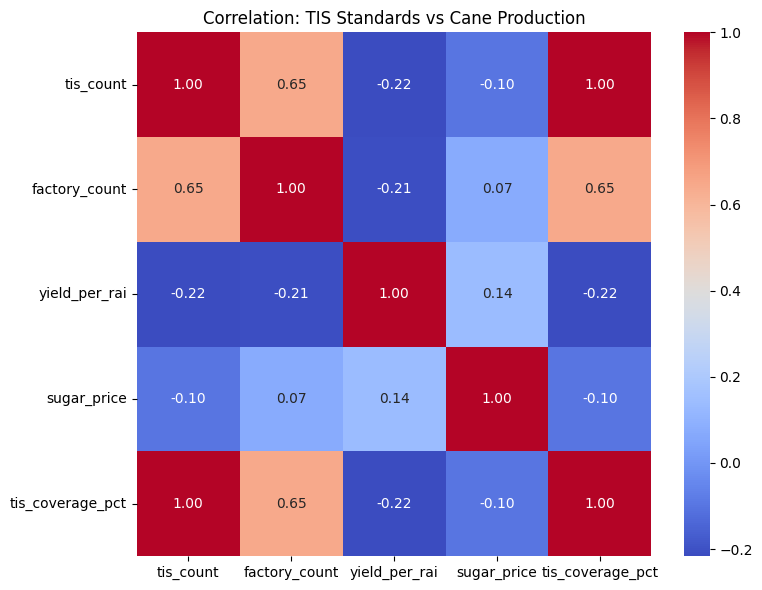

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["tis_count", "factory_count",
        "yield_per_rai", "sugar_price",
        "tis_coverage_pct"]
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True,
            cmap="coolwarm", fmt=".2f")
plt.title("Correlation: TIS Standards vs Cane Production")
plt.tight_layout()
plt.show()

---
## ส่วนที่ 16: Workshop — Clustering จังหวัด

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[["tis_count", "factory_count",
        "yield_per_rai", "total_area"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df.groupby("cluster")[
    ["tis_count", "factory_count", "yield_per_rai"]
].mean())

# Group 0 = กลุ่มนำ (มี มอก.สูง ผลผลิตดี)
# Group 3 = กลุ่มพัฒนา (มี มอก.น้อย ต้องการส่งเสริม)

         tis_count  factory_count  yield_per_rai
cluster                                         
0         8.903226      21.064516       9.697067
1         8.458333      19.208333      13.977003
2        28.064516      40.258065      11.209345
3         7.970588      18.147059      13.853806


---
## ส่วนที่ 17: Workshop — Dashboard Data

In [17]:
summary = df.groupby("province").agg({
    "tis_count": "sum",
    "factory_count": "sum",
    "total_production": "sum",
    "yield_per_rai": "mean",
    "sugar_price": "mean",
    "cluster": "first"
}).reset_index()

need_boost = summary[
    summary["cluster"].isin([3, 2])
].sort_values("total_production", ascending=False)

print(f"จังหวัดที่ต้องการส่งเสริม: {len(need_boost)} จังหวัด")
print(need_boost[["province", "tis_count",
                  "factory_count", "yield_per_rai"]])

จังหวัดที่ต้องการส่งเสริม: 10 จังหวัด
          province  tis_count  factory_count  yield_per_rai
13      Ratchaburi         71            123      12.769744
17             Tak         52            218      12.634625
14        Saraburi         84            183      12.176089
3     Kanchanaburi         92            197      12.674886
5             Loei         60            157      10.877343
12     Phitsanulok        102            138      12.469024
18      Udon Thani        100            133      12.732090
1       Chiang Mai         74            118      12.522316
2   Kamphaeng Phet         67            138      11.310525
7    Maha Sarakham         99            150      11.813665
